In [1]:
# 📦 Upload and Extract
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile, os
zip_path = '/content/archive (1).zip'
extract_path = '/content/pest-dataset/'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)
print(" Extraction Completed!")

 Extraction Completed!


In [3]:
print(os.listdir('/content/pest-dataset/pest'))

['test', 'train']


In [4]:
os.listdir('/content/pest-dataset/pest/test')
os.listdir('/content/pest-dataset/pest/train')

['mites',
 'beetle',
 'mosquito',
 'bollworm',
 'armyworm',
 'aphids',
 'sawfly',
 'stem_borer',
 'grasshopper']

In [5]:
# Install Required Libraries
!pip install tensorflow keras gradio -q

In [6]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import gradio as gr
import numpy as np

In [7]:
# Paths
train_path = '/content/pest-dataset/pest/train'
test_path = '/content/pest-dataset/pest/test'

In [8]:
# 🔄 Data Augmentation
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [9]:
train_datagen = ImageDataGenerator(
     rescale=1./255,
     validation_split=0.2,
     rotation_range=20,
     width_shift_range=0.2,
     height_shift_range=0.2,
     shear_range=0.2,
     zoom_range=0.2,
     horizontal_flip=True,
     fill_mode='nearest' )

train_generator = train_datagen.flow_from_directory(
     train_path,
     target_size=IMG_SIZE,
     batch_size=BATCH_SIZE,
     class_mode='categorical',
     subset='training',
     shuffle=True )

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False )

Found 2160 images belonging to 9 classes.
Found 540 images belonging to 9 classes.


In [10]:
#  Class Names
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


In [11]:
#  Build Model
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.6)(x)
predictions = Dense(len(class_names), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# Freeze base layers for initial training
for layer in base_model.layers:
  layer.trainable = False

In [13]:
# Compile Model (only top layers trainable)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)

In [15]:
# 🎯 Train Top Layers
EPOCHS = 10
history = model.fit( train_generator, validation_data=validation_generator,
                    epochs=EPOCHS, callbacks=[early_stop, reduce_lr] )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 76s 870ms/step - accuracy: 0.2820 - loss: 2.3574 - val_accuracy: 0.6611 - val_loss: 1.2788 - learning_rate: 0.0010
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 490ms/step - accuracy: 0.5998 - loss: 1.3581 - val_accuracy: 0.6944 - val_loss: 1.0601 - learning_rate: 0.0010
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 482ms/step - accuracy: 0.7093 - loss: 1.0650 - val_accuracy: 0.7370 - val_loss: 0.9592 - learning_rate: 0.0010
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 476ms/step - accuracy: 0.7835 - loss: 0.8586 - val_accuracy: 0.7315 - val_loss: 0.9281 - learning_rate: 0.0010
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 491ms/step - accuracy: 0.8029 - loss: 0.7896 - val_accuracy: 0.7611 - val_loss: 0.8901 - learning_rate: 0.0010
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 487ms/step - accuracy: 0.8583 - loss: 0.6381 - val_accuracy: 0.7574 - val_loss: 0.9241 - learning_rate: 0.0010
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8784 - loss: 0.5

In [16]:
# 🔓 Fine-Tuning (unfreeze last 20 layers)
for layer in base_model.layers[-20:]:
  layer.trainable = True
  model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

In [17]:
# Fine-tune for additional epochs
fine_tune_epochs = 5
history_fine = model.fit( train_generator,
                         validation_data=validation_generator,
                          epochs=fine_tune_epochs,
                          callbacks=[early_stop, reduce_lr] )

Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 64s 720ms/step - accuracy: 0.7116 - loss: 1.0261 - val_accuracy: 0.7556 - val_loss: 0.9015 - learning_rate: 1.0000e-05
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 34s 501ms/step - accuracy: 0.7982 - loss: 0.8119 - val_accuracy: 0.7556 - val_loss: 0.8759 - learning_rate: 1.0000e-05
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 485ms/step - accuracy: 0.8363 - loss: 0.7043 - val_accuracy: 0.7852 - val_loss: 0.8260 - learning_rate: 1.0000e-05
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 491ms/step - accuracy: 0.8524 - loss: 0.6307 - val_accuracy: 0.7556 - val_loss: 0.9189 - learning_rate: 1.0000e-05
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8557 - loss: 0.6078
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 492ms/step - accuracy: 0.8557 - loss: 0.6078 - val_accuracy: 0.7593 - val_loss: 0.8947 - learning_rate: 1.0000e-05


In [18]:
# 🧪 Test Evaluation
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory( test_path,
                                                  target_size=IMG_SIZE,
                                                   batch_size=1, class_mode='categorical',
                                                   shuffle=False )
loss, acc = model.evaluate(test_generator)
print(f"✅ Final Test Accuracy: {acc*100:.2f}%")

Found 450 images belonging to 9 classes.
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9333 - loss: 0.4027
✅ Final Test Accuracy: 91.11%


In [19]:
# 9️⃣ Gradio Interface for Prediction
def predict_pest(img):
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)
    class_idx = np.argmax(pred, axis=1)[0]
    return class_names[class_idx]

# Launch Gradio app
gr.Interface(
    fn=predict_pest,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=1),
    title="Pest Detection AI",
    description="Upload an image of a pest and the model will predict its type."
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fd8ef7fad025be2ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


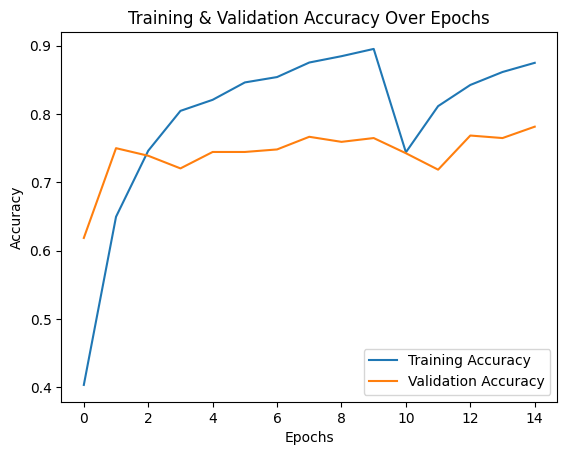

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy Over Epochs')
plt.show()
